# FV3 subcycling plotter

Examine the impact of subcycling parameters on the strength of the numerical Lamb wave in FV3 (Figure 9)

In [33]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from functions import *

In [34]:
# Compare FV3 subcycling at a resolution of C192

# Save the figures?
save_the_fig = True

res = 'C96'
#res = 'C192'

run_base = "/glade/derecho/scratch/timand/"

if res == 'C192':
    case1 = 'cam_6_4_095_lamb_fv3_C192_ztop_50km_dt_1min'
    nc_file1 = case1 + '.cam.h0i.0001-01-01-00000_p_pert_no_sponge.regrid.0.5x0.5.nc'
    label_1 = r'$k_{\text{split}} = 1, n_{\text{split}} = 1$'
    
    case2 = 'cam_6_4_095_lamb_fv3_C192_ztop_50km_dt_1min'
    nc_file2 = case2 + '.cam.h0i.0001-01-01-00000_p_pert_nsplit3_ksplit1.regrid.0.5x0.5.nc'
    label_2 = r'$k_{\text{split}} = 1, n_{\text{split}} = 3$'
    
    case3 = 'cam_6_4_095_lamb_fv3_C192_ztop_50km_dt_1min'
    nc_file3 = case3 + '.cam.h0i.0001-01-01-00000_p_pert_nsplit6_ksplit1.regrid.0.5x0.5.nc'
    label_3 = r'$k_{\text{split}} = 1, n_{\text{split}} = 6$'
    
    case4 = 'cam_6_4_095_lamb_fv3_C192_ztop_50km_dt_1min'
    nc_file4 = case4 + '.cam.h0i.0001-01-01-00000_p_pert_subcycled.regrid.0.5x0.5.nc'
    label_4 = r'$k_{\text{split}} = 2, n_{\text{split}} = 6$'
    
    case5 = 'cam_6_4_095_lamb_fv3_C192_ztop_50km_dt_1min'
    nc_file5 = case5 + '.cam.h0i.0001-01-01-00000_p_pert_nsplit12_ksplit1.regrid.0.5x0.5.nc'
    label_5 = r'$k_{\text{split}} = 1, n_{\text{split}} = 12$' 
elif res == 'C96':
    case1 = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_T0_275K_dt_1min'
    nc_file1 = case1 + '.cam.h0i.0001-01-01-00000_no_subcycle.regrid.1x1.bilinear.nc'
    label_1 = r'$k_{\text{split}} = 1, n_{\text{split}} = 1$'
    
    case2 = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_T0_275K_dt_1min'
    nc_file2 = case2 + '.cam.h0i.0001-01-01-00000_ksplit1_nsplit3.regrid.1x1.bilinear.nc'
    label_2 = r'$k_{\text{split}} = 1, n_{\text{split}} = 3$'
    
    case3 = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_T0_275K_dt_1min'
    nc_file3 = case3 + '.cam.h0i.0001-01-01-00000_ksplit1_nsplit6.regrid.1x1.bilinear.nc'
    label_3 = r'$k_{\text{split}} = 1, n_{\text{split}} = 6$'
    
    case4 = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_T0_275K_dt_1min'
    nc_file4 = case4 + '.cam.h0i.0001-01-01-00000_ksplit2_nsplit6.regrid.1x1.bilinear.nc'
    label_4 = r'$k_{\text{split}} = 2, n_{\text{split}} = 6$'
    
    case5 = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_T0_275K_dt_1min'
    nc_file5 = case5 + '.cam.h0i.0001-01-01-00000_ksplit1_nsplit12.regrid.1x1.bilinear.nc'
    label_5 = r'$k_{\text{split}} = 1, n_{\text{split}} = 12$'     
    

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3
run_path4 = run_base + case4 + '/run/' + nc_file4
run_path5 = run_base + case5 + '/run/' + nc_file5

nc1 = Dataset(run_path1, 'r')
nc2 = Dataset(run_path2, 'r')
nc3 = Dataset(run_path3, 'r')
nc4 = Dataset(run_path4, 'r')
nc5 = Dataset(run_path5, 'r')


In [35]:
time = nc1['time'][:]

# Each resolution has different lon, lat.
lat = nc1['lat'][:]
lon = nc1['lon'][:]

LON, LAT = np.meshgrid(lon, lat)

In [36]:
field_name = 'PS'

# Compute maxs at each time
field_max1 = np.zeros(len(time))
field_max2 = np.zeros(len(time))
field_max3 = np.zeros(len(time))
field_max4 = np.zeros(len(time))
field_max5 = np.zeros(len(time))

if field_name == 'PS':
    p0 = 1e5
    print('yup')
    for i in np.arange(len(time)):
        field_max1[i] = np.max(nc1[field_name][i, :]) - p0
        field_max2[i] = np.max(nc2[field_name][i, :]) - p0
        field_max3[i] = np.max(nc3[field_name][i, :]) - p0
        field_max4[i] = np.max(nc4[field_name][i, :]) - p0
        field_max5[i] = np.max(nc5[field_name][i, :]) - p0
else:
    field_max1 = np.max(nc1[field_name][:], axis=(1,2))
    field_max2 = np.max(nc2[field_name][:], axis=(1,2))
    field_max3 = np.max(nc3[field_name][:], axis=(1,2))

yup


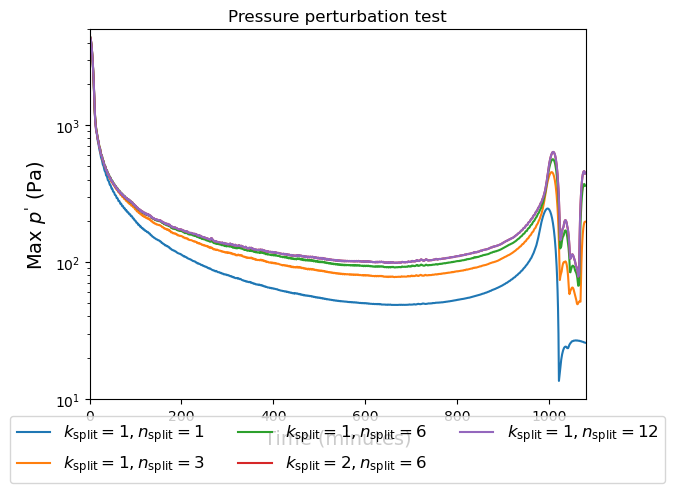

In [37]:
time_mins = time*24*60
end_idx = len(time)

t_end = -1
plt.figure()
plt.semilogy(time_mins[0:t_end], field_max1[0:t_end], label=label_1)
plt.semilogy(time_mins[0:t_end], field_max2[0:t_end], label=label_2)
plt.semilogy(time_mins[0:t_end], field_max3[0:t_end], label=label_3)
plt.semilogy(time_mins[0:t_end], field_max4[0:t_end], label=label_4)
plt.semilogy(time_mins[0:t_end], field_max5[0:t_end], label=label_5)
plt.xlim([time_mins[0],time_mins[t_end]])

if field_name == 'PS':
    plt.ylabel(r"Max $p^'$ (Pa)", size=14)
    plt.title('Pressure perturbation test')
    plt.ylim([10,5000])
else:
    plt.ylabel(f'{field_name} maximum',size=14)
    plt.title('Acid test')
    #plt.ylim([0,2])

plt.xlabel('Time (minutes)', size=14)
plt.legend(loc='lower center', prop={'size': 12}, bbox_to_anchor=(0.5, -0.25), ncol=3)


In [38]:
# Instead, plot the amplitude at the antipode at all times:
if res == 'C96':
    lon_a_idx = 90
    lat_a_idx = 90
    lon_inds = np.array([120, 140, 160, 180, 200, 220, 240])
elif res == 'C192':
    lon_a_idx = 180
    lat_a_idx = 180
    lon_inds = 2*np.array([120, 140, 160, 180, 200, 220, 240])

antipodal_p1 = nc1[field_name][:, lat_a_idx, lon_a_idx] - p0
antipodal_p2 = nc2[field_name][:, lat_a_idx, lon_a_idx] - p0
antipodal_p3 = nc3[field_name][:, lat_a_idx, lon_a_idx] - p0
antipodal_p4 = nc4[field_name][:, lat_a_idx, lon_a_idx] - p0
antipodal_p5 = nc5[field_name][:, lat_a_idx, lon_a_idx] - p0

In [44]:
# What are the estimation speeds??
# Use the maximum method
lamb_times1, lamb_speed1 = find_lamb_wave(nc1[field_name][:, lat_a_idx, :] - p0, time, lon, lon_inds)
lamb_times2, lamb_speed2 = find_lamb_wave(nc2[field_name][:, lat_a_idx, :] - p0, time, lon, lon_inds)
lamb_times3, lamb_speed3 = find_lamb_wave(nc3[field_name][:, lat_a_idx, :] - p0, time, lon, lon_inds)
lamb_times4, lamb_speed4 = find_lamb_wave(nc4[field_name][:, lat_a_idx, :] - p0, time, lon, lon_inds)
lamb_times5, lamb_speed5 = find_lamb_wave(nc5[field_name][:, lat_a_idx, :] - p0, time, lon, lon_inds)

In [45]:
print('Expected Lamb wave speed is 329.7')
print(f'{label_1}: {lamb_speed1}')
print(f'{label_2}: {lamb_speed2}')
print(f'{label_3}: {lamb_speed3}')
print(f'{label_4}: {lamb_speed4}')
print(f'{label_5}: {lamb_speed5}')

Expected Lamb wave speed is 329.7
$k_{\text{split}} = 1, n_{\text{split}} = 1$: 328.95491432329095
$k_{\text{split}} = 1, n_{\text{split}} = 3$: 327.089066025785
$k_{\text{split}} = 1, n_{\text{split}} = 6$: 326.3690285120135
$k_{\text{split}} = 2, n_{\text{split}} = 6$: 325.95901846466865
$k_{\text{split}} = 1, n_{\text{split}} = 12$: 325.95901846466865


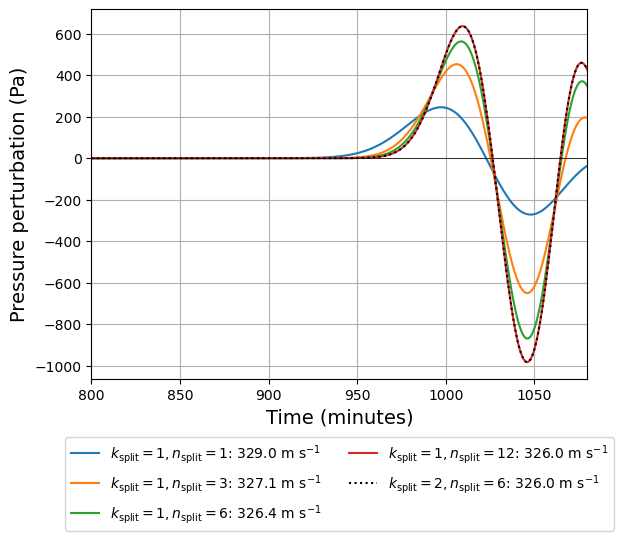

In [51]:
t_end = -1
t_min = 800
plt.figure()
plt.plot(time_mins[t_min:], antipodal_p1[t_min:], label=f'{label_1}: {lamb_speed1:.1f}' r' m s$^{-1}$')#, c='b')
plt.plot(time_mins[t_min:], antipodal_p2[t_min:], label=f'{label_2}: {lamb_speed2:.1f}' r' m s$^{-1}$')#, c='b',linestyle='--')
plt.plot(time_mins[t_min:], antipodal_p3[t_min:], label=f'{label_3}: {lamb_speed3:.1f}' r' m s$^{-1}$')#, c='r')
plt.plot(time_mins[t_min:], antipodal_p4[t_min:], label=f'{label_5}: {lamb_speed5:.1f}' r' m s$^{-1}$')
plt.plot(time_mins[t_min:], antipodal_p5[t_min:], label=f'{label_4}: {lamb_speed4:.1f}' r' m s$^{-1}$', linestyle='dotted',c='k')#, c='r', linestyle='dotted')
plt.plot(time_mins[t_min:], np.zeros(len(time_mins[t_min:])), c='k', linewidth=0.5)
plt.xlim([time_mins[t_min],time_mins[t_end]])

plt.ylabel('Pressure perturbation (Pa)', size=14)
plt.xlabel('Time (minutes)', size=14)
plt.legend(loc='lower center', prop={'size': 10}, bbox_to_anchor=(0.5, -0.43), ncol=2)
plt.grid()

plt.savefig(f'figures/lamb_fv3_{res}_subcycling', bbox_inches='tight')

634.0156
[   0.          -3.328125    -5.8046875 ... -170.3984375 -171.0859375
 -168.796875 ]


Text(0, 0.5, 'Difference (Pa)')

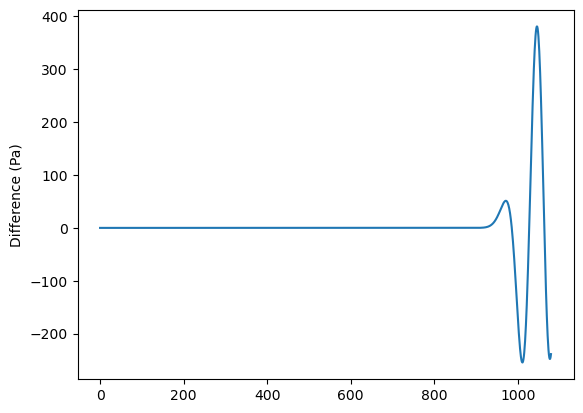

In [42]:
diff = nc1[field_name][:, lat_a_idx_C96, lon_a_idx_C96] - nc2[field_name][:, lat_a_idx_C96, lon_a_idx_C96][:]
print(np.sum(diff))

max_diff = field_max1 - field_max2
print(max_diff)

plt.figure()
plt.plot(time_mins[0:t_end], antipodal_p1[0:t_end]-antipodal_p2[0:t_end])
plt.ylabel('Difference (Pa)')

In [43]:
# What about comparing the fields??
# Give the time index
t_idx = 720
#t_idx = 1000
t_min = int(np.round(time[t_idx]*24*60, 0))
print(t_min)

if field_name == 'PS':
    field_plot1 = field1[t_idx, :, :]-p0
    field_plot2 = field2[t_idx, :, :]-p0
    field_plot3 = field3[t_idx, :, :]-p0
    conts = np.linspace(0,50,11)
    cmap='viridis'
else:
    se_plot = field_se[t_idx, :, :]
    fv3_plot = field_fv3[t_idx, :, :]
    mpas_plot = field_mpas[t_idx, :, :]

print(conts)

fig, axes = plt.subplots(1,3, figsize=(15,5), sharey = True)
ax1, ax2, ax3 = axes

plot1 = ax1.contourf(LON1, LAT1, field_plot1, levels = conts, extend='both', cmap=cmap)
plot2 = ax2.contourf(LON2, LAT2, field_plot2, levels = conts, extend='both', cmap=cmap)
plot3 = ax3.contourf(LON3, LAT3, field_plot3, levels = conts, extend='both', cmap=cmap)

cb = plt.colorbar(plot3, ax=axes, shrink=0.7, pad=0.15, aspect=60, location='bottom')
if field_name == 'PS':
    ax1.set_title(f'C48 \n min = {np.min(field_plot1):.1f} Pa \n max = {np.max(field_plot1):.1f} Pa', size=14)
    ax2.set_title(f'C96 \n min = {np.min(field_plot2):.1f} Pa \n max = {np.max(field_plot2):.1f} Pa', size=14)
    ax3.set_title(f'C192 \n min = {np.min(field_plot3):.1f} Pa \n max = {np.max(field_plot3):.1f} Pa', size=14)
    cb.set_label('Pressure perturbation (Pa)', size=12)
elif field_name == 'OMEGA850':
    ax1.set_title(f'SE \n min = {np.min(se_plot):.1f} \n max = {np.max(se_plot):.1f}')
    ax2.set_title(f'FV3 \n min = {np.min(fv3_plot):.1f} \n max = {np.max(fv3_plot):.1f}')
    ax3.set_title(f'MPAS \n min = {np.min(mpas_plot):.1f} \n max = {np.max(mpas_plot):.1f}')
    cb.set_label(r'Maximum vertical pressure velocity (Pa s$^{-1}$', size=12)

ax1.set_ylabel('Latitude (deg)', size=14)
ax2.set_xlabel('Longitude (deg)', size=14)

for ax in axes.flatten():
    ax.set_xticks(np.linspace(0,360,7))
    ax.set_aspect('equal')
    
ax2.set_xticks(np.linspace(0,360,7))
ax3.set_xticks(np.linspace(0,360,7))
ax1.set_yticks(np.linspace(-90,90,7))

plt.show()


720


NameError: name 'field1' is not defined